In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Leggo il csv creando un dataframe df
df = pd.read_csv('titanic_sub.csv')

# Dò un primo sguardo alle prime righe del df
df.head()

,PassengerId,Sex,Age,Pclass,Embarked,Survived
0,1,male,22.0,3,S,0
1,2,female,38.0,1,C,1
2,3,female,26.0,3,S,1
3,4,female,35.0,1,S,1
4,5,male,35.0,3,S,0


In [3]:
# Convertire tutti i nomi delle colonne in minuscolo
df.columns = df.columns.str.lower()
df.columns

Index(['passengerid', 'sex', 'age', 'pclass', 'embarked', 'survived'], dtype='object')

In [4]:
# Controllo che non ci siano casi duplicati ritornando il numero totale di righe duplicate
df.duplicated().sum()

# Se ci fossero stai dei duplicati sarebbero stati tolti con
#df = df.drop_duplicates(ignore_index=True)

0

In [5]:
# Imposta la colonna 'passengerid' come indice
df = df.set_index('passengerid')
# Dò un sguardo alla modifica apportata
df.head()

,sex,age,pclass,embarked,survived
passengerid,,,,,
1,male,22.0,3,S,0
2,female,38.0,1,C,1
3,female,26.0,3,S,1
4,female,35.0,1,S,1
5,male,35.0,3,S,0


In [6]:
# Controllo che non ci siano casi duplicati ritornando il numero totale di righe duplicate
df.index.duplicated().sum()
# Se ci fossero stai dei duplicati, avrei lavorato sugli indici e sarebbero stati tolti con
#df.drop(df.index[df.index.duplicated(keep='first')])

0

In [7]:
# Analizzo le varie informazioni del df
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   sex       891 non-null    object 
 1   age       714 non-null    float64
 2   pclass    891 non-null    int64  
 3   embarked  889 non-null    object 
 4   survived  891 non-null    int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 74.1+ KB


In [8]:
# Controllo che per ogni colonna se ci sono e la quantità di valori nan
df.isnull().sum()

sex           0
age         177
pclass        0
embarked      2
survived      0
dtype: int64

In [9]:
# Sostistuisco i valori nan nella colonna 'age' con la rispetrtiva mediana
df['age'] = df['age'].fillna(df['age'].median())

In [10]:
# Controllo che per ogni colonna se ci sono e la quantità di valori nan
df.isnull().sum()

sex         0
age         0
pclass      0
embarked    2
survived    0
dtype: int64

In [11]:
# Creare la colonna 'sex_male' One-Hot per 'sex' usando get_dummies, e modificare direttamente nel DataFrame originale
df['sex_male'] = pd.get_dummies(df['sex'], prefix='', drop_first=True)

# Mostro il df con modifiche
df.head()

,sex,age,pclass,embarked,survived,sex_male
passengerid,,,,,,
1,male,22.0,3,S,0,True
2,female,38.0,1,C,1,False
3,female,26.0,3,S,1,False
4,female,35.0,1,S,1,False
5,male,35.0,3,S,0,True


In [ ]:
# Creare le colonne One-Hot per 'embarked' usando get_dummies e aggiungerle direttamente al DataFrame
df_dummies = pd.get_dummies(df['embarked'], prefix='', prefix_sep='')

# Rendi i nomi delle colonne in minuscolo
df_dummies.columns = df_dummies.columns.str.lower()

# Aggiungi direttamente al DataFrame originale
df[df_dummies.columns] = df_dummies
# Mostro il df con modifiche
df.head()

,sex,age,pclass,embarked,survived,sex_male,c,q,s
passengerid,,,,,,,,,
1,male,22.0,3,S,0,True,False,False,True
2,female,38.0,1,C,1,False,True,False,False
3,female,26.0,3,S,1,False,False,False,True
4,female,35.0,1,S,1,False,False,False,True
5,male,35.0,3,S,0,True,False,False,True


Profondità: 2, Performance sulla validazione: 0.7664670658682635
Profondità: 5, Performance sulla validazione: 0.7964071856287425
Profondità: 10, Performance sulla validazione: 0.7844311377245509
Profondità: 25, Performance sulla validazione: 0.7964071856287425

La miglior profondità per il modello è: 5 con un punteggio di validazione di: 0.7964071856287425
Accuracy: 0.8609865470852018 

Confusion Matrix:
[[134   9]
 [ 22  58]] 

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.94      0.90       143
           1       0.87      0.72      0.79        80

    accuracy                           0.86       223
   macro avg       0.86      0.83      0.84       223
weighted avg       0.86      0.86      0.86       223



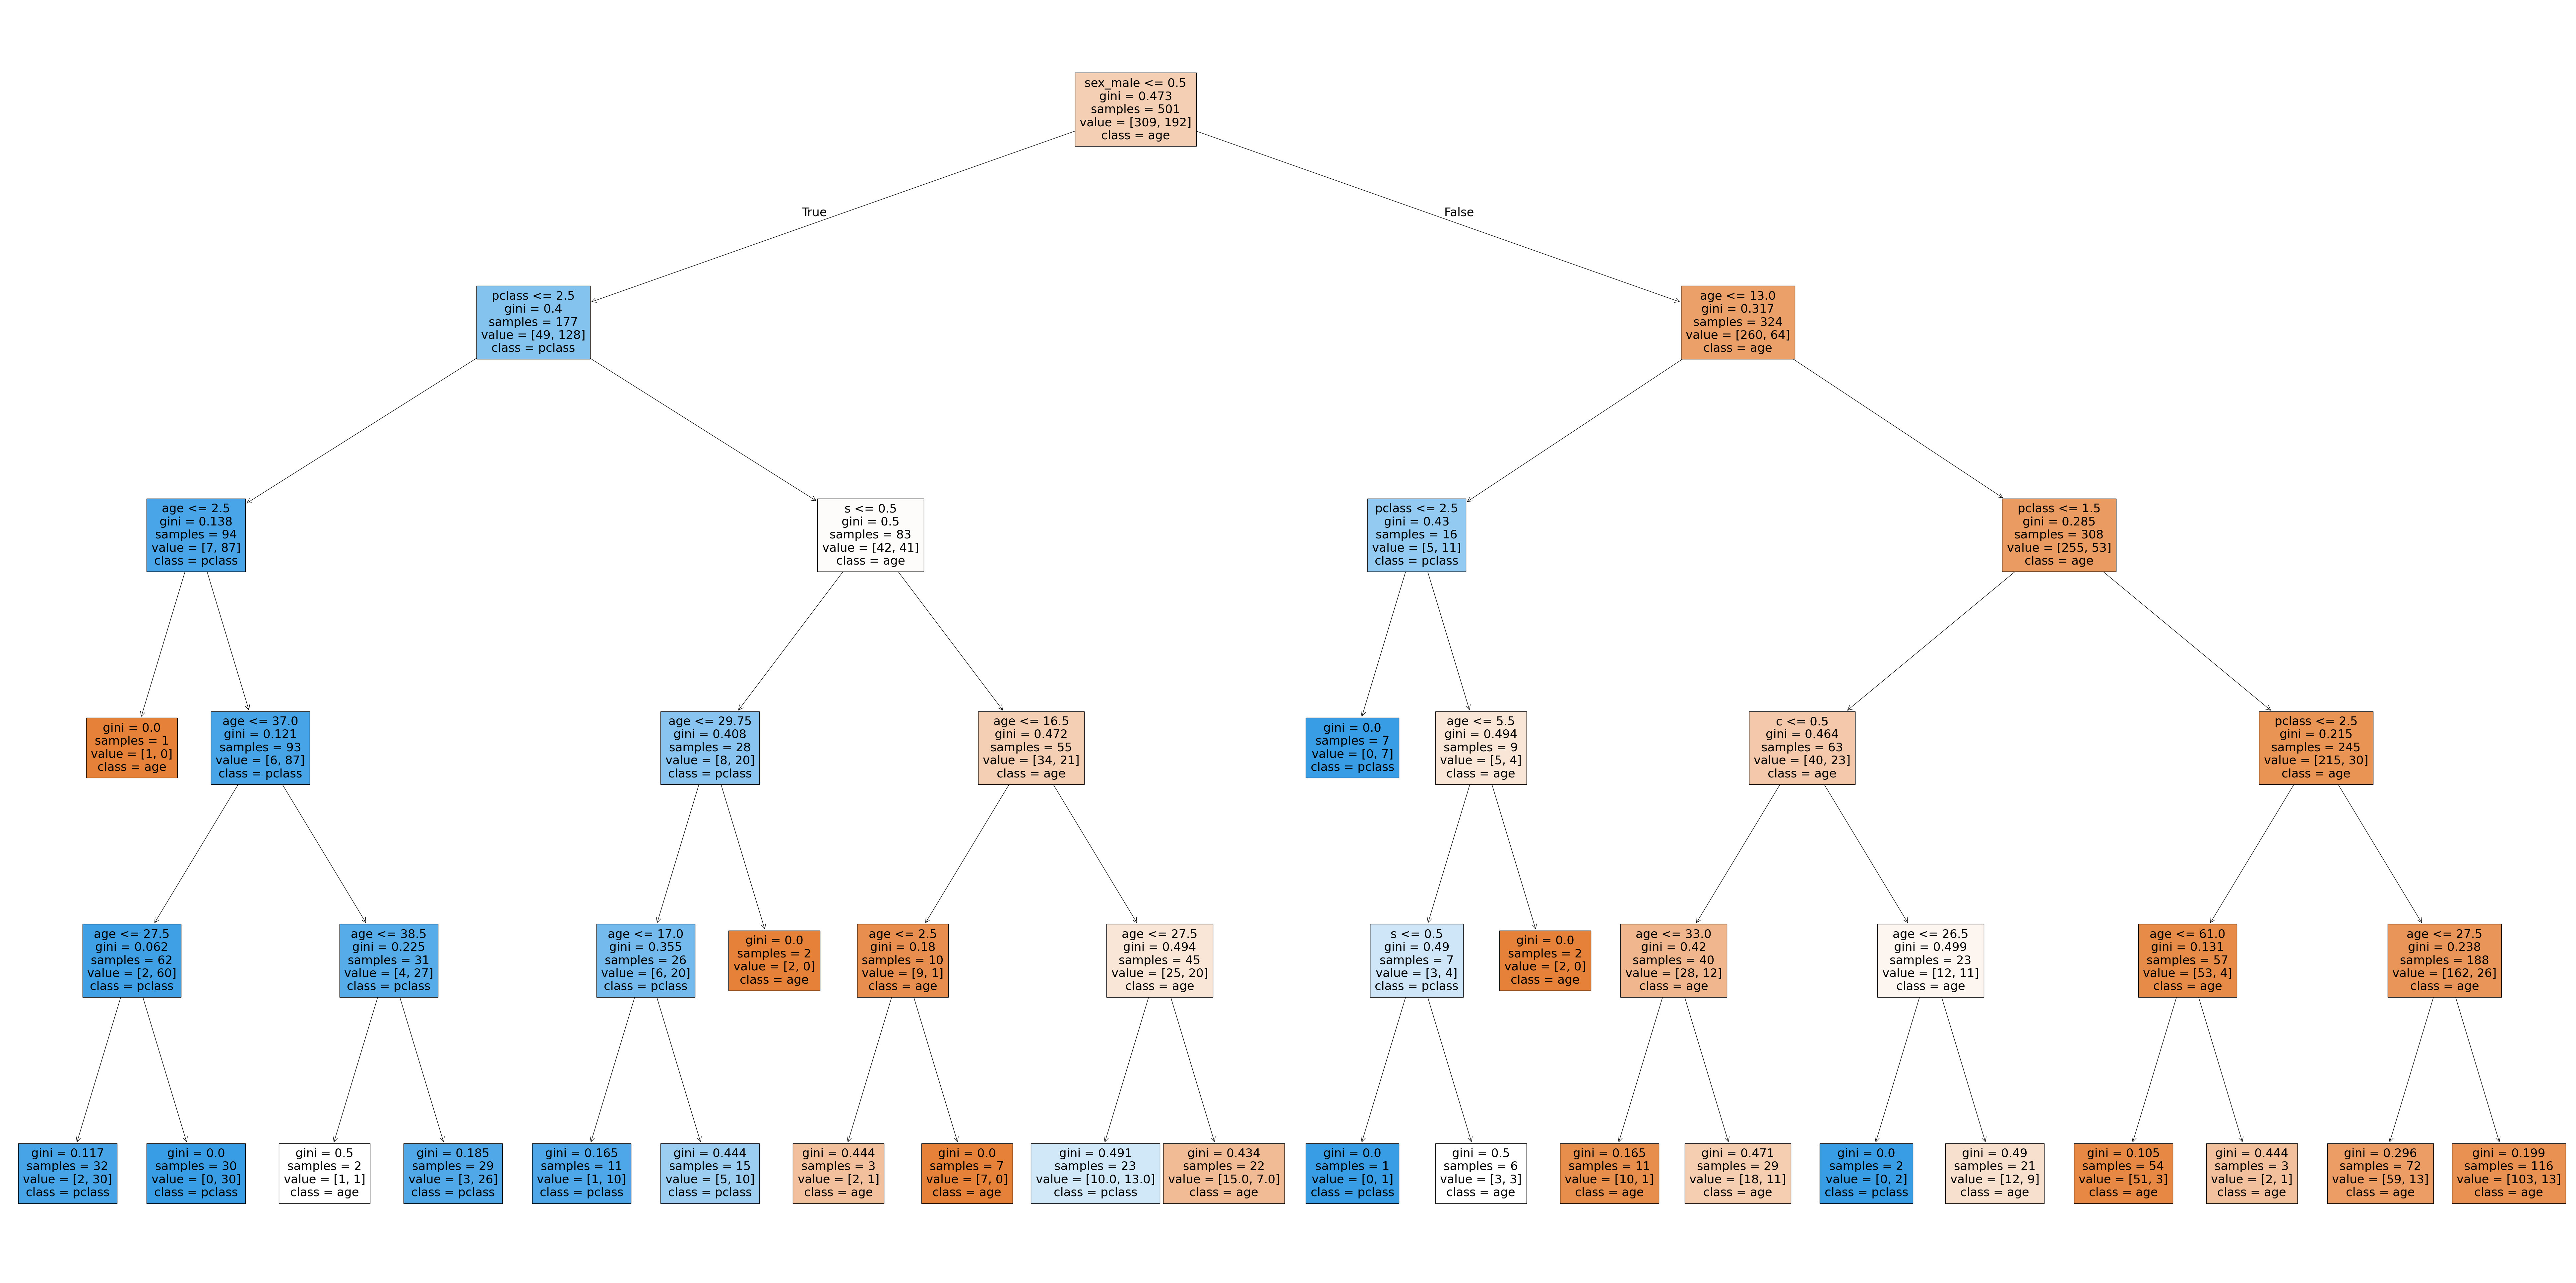

In [ ]:
# Impostare il seed per la riproducibilità
np.random.seed(0)

# Selezioniamo le feature (variabili predittive) e il target (variabile da prevedere)
features = df[['age','pclass','c','q','s', 'sex_male']] # Le colonne scelte come variabili indipendenti
target = df['survived']  # La colonna 'survived' è il target

# Divido le feature dal target per creare X (features) e y (target)
X = features
y = target  # Target (classe), che in questo caso è la sopravvivenza

# Suddividere i dati in set di addestramento (75%) e di test (25%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=78) # 78 + mediana

# Creazione del set di validazione (25%) dal set di train precedente
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=78) # 78 + median

# Variabili per confornto
best_depth = None  # Inizializza la variabile per la miglior profondità
best_score = 0  # Inizializza il punteggio di validazione più basso
best_model = 0  # Inizializza il miglior modello (indicato come 0 per ora)

# # Ciclo per testare diverse profondità dell'albero decisionale
for depth in [2, 5, 10, 25]:
    # Creare un modello di Albero Decisionale con la profondità attuale
    model = DecisionTreeClassifier(max_depth=depth)  # Crea il modello con la profondità attuale
    
    # Addestrare il modello sui dati di addestramento
    model.fit(X_train, y_train)  # Adatta il modello ai dati di addestramento (X_train, y_train)

    # Calcoliamo l'accuratezza sul set di validazione
    valid_score = model.score(X_val, y_val)  # Calcola l'accuratezza sul set di validazione (X_val, y_val)

    print(f"Profondità: {depth}, Performance sulla validazione: {valid_score}")  # Stampa il risultato

    # Se la performance è migliore, salviamo questa profondità
    if valid_score > best_score:  # Confronta se il punteggio di validazione è migliore di quello precedente
        best_score = valid_score  # Aggiorna il miglior punteggio
        best_depth = depth  # Salva la profondità migliore
        best_model = model  # Salva il miglior modello

# Stampa la profondità migliore trovata e il suo punteggio di validazione
print(f"\nLa miglior profondità per il modello è: {best_depth} con un punteggio di validazione di: {best_score}")  # Risultato finale

# Addestrare il miglior modello sui dati di addestramento
best_model.fit(X_train, y_train)  # Riaddestra il miglior modello sui dati di addestramento

# Fare delle previsioni sui dati di test
y_pred = best_model.predict(X_test)  # Fai delle previsioni sui dati di test

# Calcolare l'accuratezza
accuracy = accuracy_score(y_test, y_pred)  # Calcola l'accuratezza confrontando le previsioni con il target
print(f"Accuracy: {accuracy} \n")  # Stampa l'accuratezza

# Matrice di confusione
print("Confusion Matrix:")  # Stampa "Confusion Matrix:"
print(confusion_matrix(y_test, y_pred), '\n')  # Calcola e stampa la matrice di confusione

# Report di classificazione (precision, recall, f1-score)
print("Classification Report:")  # Stampa "Classification Report:"
print(classification_report(y_test, y_pred))  # Calcola e stampa il report di classificazione (precisione, recall, F1-score)

# Visualizzare l'albero decisionale
plt.figure(figsize=(100, 50))  # Imposta la dimensione della figura per il grafico
plot_tree(best_model, filled=True, feature_names=features.columns, class_names=features.columns)  # Disegna l'albero decisionale
plt.show()  # Mostra il grafico